In [2]:
# Import libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
#Reading dataset
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
sd = pd.read_csv(titanic_url)

In [4]:
# describtion
sd.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
#Finding if there are any null values in the data
sd.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
#Features and target
X = sd[['Pclass', 'Sex', 'Age', 'Fare']]
y = sd['Survived']

# 3. Column types
num_features = ['Age', 'Fare']
cat_features = ['Sex', 'Pclass']

In [7]:
# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# Full pipeline
model = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression())
])

In [8]:
#  Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model.fit(X_train, y_train)

#  Prediction
y_pred = model.predict(X_test)

In [9]:
# Accuracy
print("Predictions:", y_pred)
print("Actual:", y_test.values)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("classification report: ", classification_report(y_test, y_pred))
print("confusion matrix: ", confusion_matrix(y_test, y_pred))

Predictions: [0 0 0 1 1 1 1 0 1 1 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 0 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 1 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 1 1 1]
Actual: [1 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 1 0 1
 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 0 0 0 0 1 0 1 1 1
 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 1 1
 0 1 1 0 0 0 0 1 0 0 1 1 1 0 1 1 0 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 1 0 0 1 1 1 0 0 0 1 1 1]
Accuracy: 0.7988826815642458
classification report:                precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                      

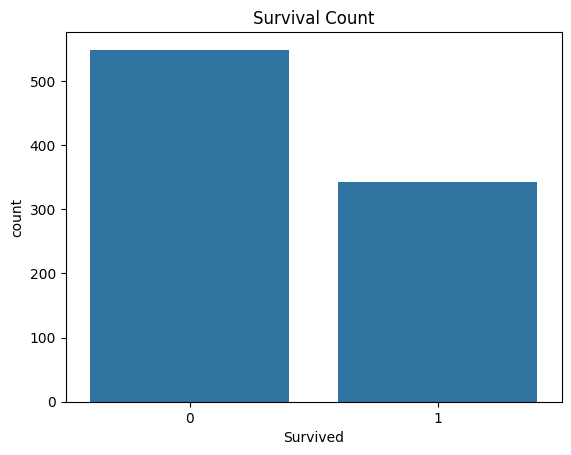

In [10]:
sns.countplot(x='Survived', data=sd)
plt.title("Survival Count")
plt.show()

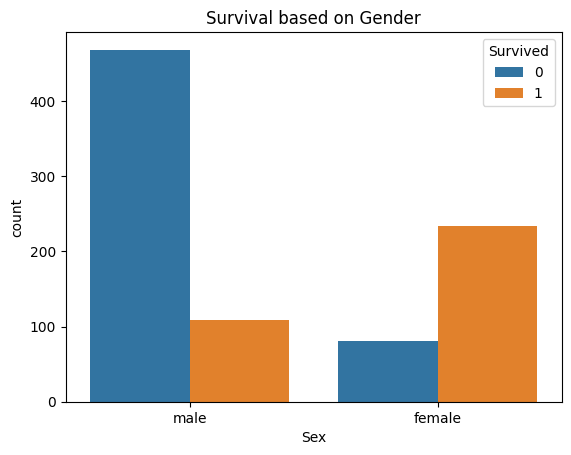

In [11]:
sns.countplot(x='Sex', hue='Survived', data=sd)
plt.title("Survival based on Gender")
plt.show()

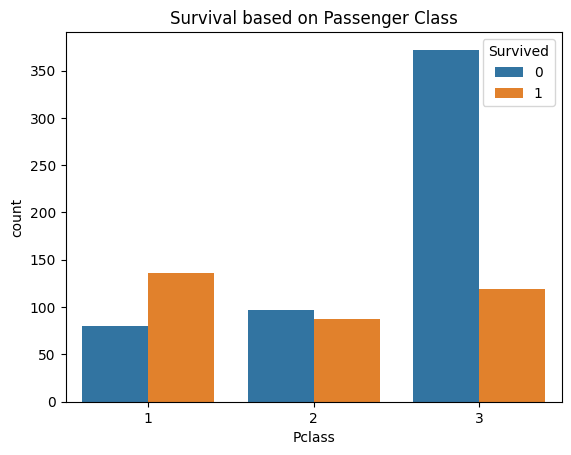

In [12]:
sns.countplot(x='Pclass', hue='Survived', data=sd)
plt.title("Survival based on Passenger Class")
plt.show()

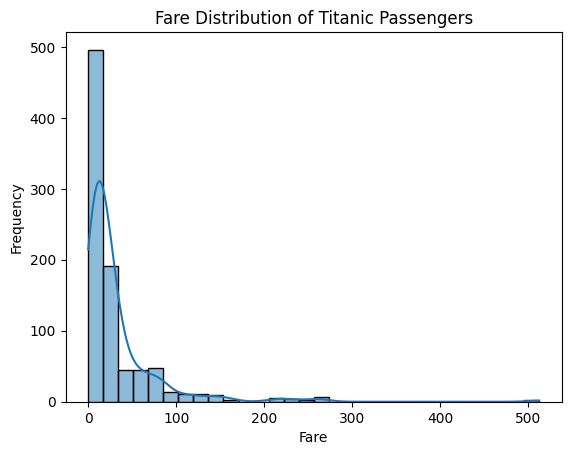

In [13]:
plt.figure()
sns.histplot(sd['Fare'], bins=30, kde=True)

plt.title("Fare Distribution of Titanic Passengers")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

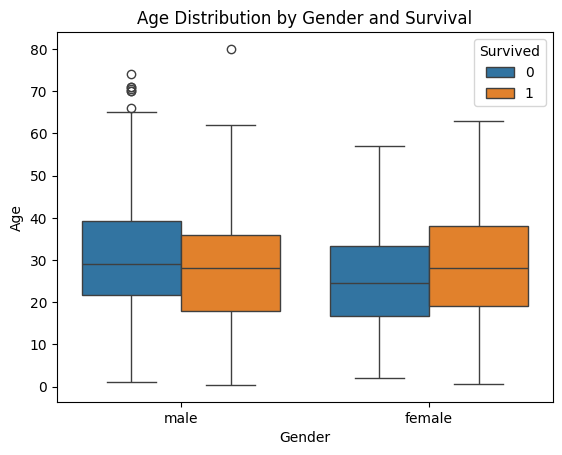

In [14]:
plt.figure()

sns.boxplot(x='Sex', y='Age', hue='Survived', data=sd)

plt.title("Age Distribution by Gender and Survival")
plt.xlabel("Gender")
plt.ylabel("Age")

plt.show()

<Axes: ylabel='Count'>

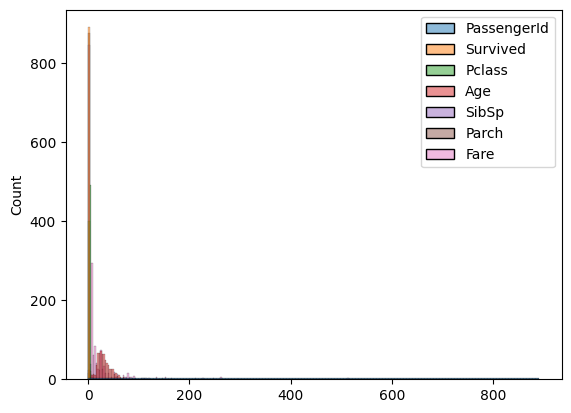

In [15]:
sns.histplot(sd)

<Axes: >

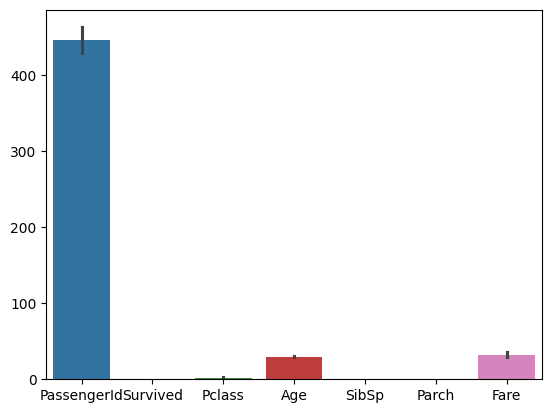

In [16]:
sns.barplot(sd)

<Axes: >

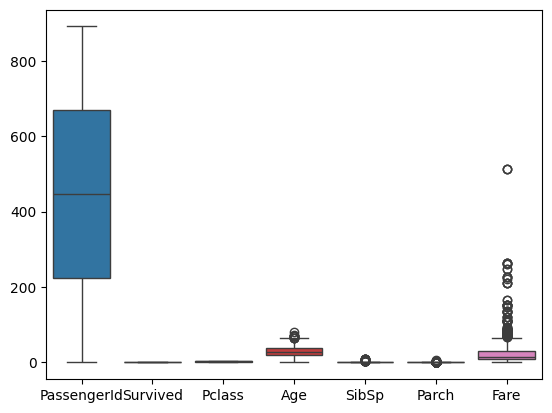

In [17]:
sns.boxplot(sd)